<a href="https://colab.research.google.com/github/Ali-Hamza-developer/flyrank-ml-internship/blob/main/work/notebooks/capstone.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Capstone — mirrors your deployed research paper

Lane: **Content Refresh Prioritization (Refresh / Content Opportunity Scoring)**

Run top to bottom (Runtime → Run all). Requires `HF_TOKEN` Colab Secret, same as w03-w07.

This notebook does not re-derive anything new — it pulls together what w03-w07 already
established and validated, in the order the deployed paper presents it.

In [1]:
!pip install -q duckdb scikit-learn

import duckdb
import pandas as pd
import numpy as np
from google.colab import userdata

HF_TOKEN = userdata.get('HF_TOKEN')
con = duckdb.connect()
con.execute(f"CREATE SECRET (TYPE huggingface, TOKEN '{HF_TOKEN}')")

REL = "hf://datasets/FlyRank/internship-warehouse"
MONTH = "2026-03"  # mid-panel month, matches w03-w07, never the sealed _sample
print('DuckDB ready, target month =', MONTH)

DuckDB ready, target month = 2026-03


## 1. Question

*The research question and the decision it supports.*

**Research question:** which web pages should FlyRank content teams prioritize for review,
based on prior-90-day search performance?

**Unit of analysis:** one web page (`client_hash_id` + `content_hash_id`), scored on the
prior-90-day window ending March 2026.

**Decision supported:** which pages an SEO analyst opens first in a fixed-size review
queue. **Action taken:** the analyst reviews, rewrites, or refreshes the flagged pages.
**Cost of a wrong call:** a genuinely declining page is missed, or analyst time is spent on
a page that didn't need it — both real, both recoverable, neither safety-critical.

**Why ML helps:** a fixed rule can only weigh a couple of conditions at once. Page
performance depends on several interacting signals — impressions, position, CTR,
staleness, content type. A model can learn these interactions directly instead of relying
on one hand-tuned linear rule.

## 2. Data

*Which release, which tables, date windows, what you excluded and why. Public-safe.*

In [2]:
# Feature base — same construction as w03/w05/w06/w07: 90-day feature window (month=2026-03),
# joined to dim_content. No future-window or rebuilt product-flag columns.
base = con.sql(f"""
    WITH window_90d AS (
        SELECT
            client_hash_id,
            content_hash_id,
            SUM(gsc_impressions) AS impressions_90d,
            SUM(gsc_clicks) AS clicks_90d,
            AVG(gsc_avg_position) AS avg_position_90d
        FROM read_parquet('{REL}/fact_content_daily_performance/month={MONTH}/data_0.parquet')
        WHERE gsc_data_available IS TRUE
        GROUP BY 1, 2
    )
    SELECT
        w.client_hash_id,
        w.content_hash_id,
        w.impressions_90d,
        LOG(1 + w.impressions_90d) AS log_impressions_90d,
        w.avg_position_90d,
        CASE WHEN w.impressions_90d > 0 THEN w.clicks_90d::DOUBLE / w.impressions_90d ELSE NULL END AS ctr_90d,
        (DATE '2026-03-31' - COALESCE(d.last_optimized_date, d.content_created_date)) AS days_since_last_update,
        d.word_count,
        d.content_type,
        d.main_intent,
        d.competition_level
    FROM window_90d w
    JOIN read_parquet('{REL}/dim_content.parquet') d
      ON w.content_hash_id = d.content_hash_id AND w.client_hash_id = d.client_hash_id
    WHERE w.impressions_90d > 0
      AND (DATE '2026-03-31' - COALESCE(d.last_optimized_date, d.content_created_date)) >= 0
""").df()

print('rows:', len(base))
print('distinct clients:', base['client_hash_id'].nunique())
base.head()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

rows: 136974
distinct clients: 47


,client_hash_id,content_hash_id,impressions_90d,log_impressions_90d,avg_position_90d,ctr_90d,days_since_last_update,word_count,content_type,main_intent,competition_level
0,client_e547b89c05043229,content_1658a3da0f037fc1,877.0,2.943495,3.609769,0.000000,375,2723,keyword article,commercial,LOW
1,client_e547b89c05043229,content_b186c2501b93f989,1226.0,3.088845,4.619496,0.000816,375,2778,keyword article,informational,LOW
2,client_e547b89c05043229,content_fca5b5b61faa99c8,663.0,2.822168,2.762072,0.000000,375,<NA>,keyword article,informational,LOW
3,client_e547b89c05043229,content_00c8400a417a7dde,359.0,2.556303,40.406495,0.000000,375,<NA>,keyword article,commercial,LOW
4,client_e547b89c05043229,content_aab93985444a0293,937.0,2.972203,29.255660,0.003202,375,1909,keyword article,transactional,LOW


**Release / tables:** `FlyRank/internship-warehouse` on Hugging Face —
`fact_content_daily_performance` (feature window `month=2026-03`, label window
`month=2026-04`) joined to `dim_content`. Mid-panel month, never the sealed `_sample`.

**Deliberately excluded:**
- `health_score`, `priority_score`, `action_type` — rebuilt product flags, not shipped in
  this release; feeding a rebuilt version back in as a feature causes a circular result.
- `next_30d_impressions_delta` — built directly from the label window; demonstrated leak
  (inflates AUC to 1.000), removed.
- `client_hash_id` / `content_hash_id` — join and grouping keys only, never features.
- Raw query text, URLs, titles, or any client-identifying field — not present in this
  release, and would violate public-safe rules even if they were.
- Any GA4 field where GA4 tracking wasn't active — absence of tracking is not absence of
  activity.

**Public-safe confirmation:** nothing client-identifying appears anywhere above — the
release ships pre-anonymized to hashed IDs.

## 3. Methodology

*Assumptions, features, label definition, baseline, validation design, leakage checks.*

In [3]:
# Label: 30-day forward window, separate month partition (month=2026-04) — never overlaps the feature window
label_window = con.sql(f"""
    SELECT client_hash_id, content_hash_id, SUM(gsc_impressions) AS impressions_next30
    FROM read_parquet('{REL}/fact_content_daily_performance/month=2026-04/data_0.parquet')
    WHERE report_date <= DATE '2026-04-30'
    GROUP BY 1, 2
""").df()

modeling_df = base.merge(label_window, on=['client_hash_id', 'content_hash_id'], how='inner')
modeling_df['future_decline'] = (
    modeling_df['impressions_next30'] < 0.7 * modeling_df['impressions_90d']
).astype(int)
modeling_df = modeling_df.drop(columns=['impressions_next30'])  # label-window column never reaches the feature matrix

base_rate = modeling_df['future_decline'].mean()
print('rows:', len(modeling_df), '| clients:', modeling_df['client_hash_id'].nunique())
print('base rate of future_decline (majority-class check):', round(base_rate, 3))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

rows: 136973 | clients: 47
base rate of future_decline (majority-class check): 0.514


**Target/proxy, one sentence:** `future_decline` = 1 if a page's next-30-day impressions
fall below 70% of its prior-90-day impressions, else 0.

**Baseline rule (w04):** flag a page when it has real visibility (≥250 impressions) AND
at least one of: CTR under-captures for its position tier (position ≤20, CTR under 70% of
the tier's expected CTR), or it hasn't been touched in 180+ days. Uses only the same
leakage-safe, prior-window features the model uses — a fair comparison point.

**Features (honest, 5):** `log_impressions_90d`, `avg_position_90d`, `ctr_90d`,
`days_since_last_update`, `word_count`. **Extended for the tree model (+3):**
`content_type`, `main_intent`, `competition_level`.

**Validation design:** grouped by `client_hash_id` (`GroupShuffleSplit`, test_size=0.25,
random_state=42) — not a random row split, so no client's content appears in both train
and test.

In [4]:
from sklearn.model_selection import GroupShuffleSplit, train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import roc_auc_score

features_honest = ['log_impressions_90d', 'avg_position_90d', 'ctr_90d',
                    'days_since_last_update', 'word_count']
features_context = features_honest + ['content_type', 'main_intent', 'competition_level']

# Honest, client-grouped split (the one used for every real number below)
gss = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=42)
train_idx, test_idx = next(gss.split(modeling_df, groups=modeling_df['client_hash_id']))
train_df, test_df = modeling_df.iloc[train_idx].copy(), modeling_df.iloc[test_idx].copy()
print('client overlap (must be empty):',
      set(train_df['client_hash_id']).intersection(test_df['client_hash_id']))

# --- Leakage checks: attach a future-window leak, a label-derived leak, and a rebuilt-flag
# leak to the honest feature set, and show each inflates (or doesn't) AUC ---
attack_df = modeling_df.merge(label_window, on=['client_hash_id', 'content_hash_id'], how='left')
attack_df['impressions_next30'] = attack_df['impressions_next30'].fillna(0)
attack_df['next_30d_impressions_delta'] = attack_df['impressions_next30'] - attack_df['impressions_90d']
attack_df['decline_flag_leak'] = attack_df['future_decline']
attack_df['rebuilt_priority_flag'] = (
    (attack_df['avg_position_90d'] > 10).astype(int) + (attack_df['ctr_90d'].fillna(0) < 0.02).astype(int)
)

gss2 = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=42)
tr_idx2, te_idx2 = next(gss2.split(attack_df, groups=attack_df['client_hash_id']))
train_a, test_a = attack_df.iloc[tr_idx2].copy(), attack_df.iloc[te_idx2].copy()

def fit_auc(train_df_, test_df_, feats):
    tr = train_df_.dropna(subset=feats + ['future_decline'])
    te = test_df_.dropna(subset=feats + ['future_decline'])
    clf = LogisticRegression(max_iter=1000).fit(tr[feats], tr['future_decline'])
    return roc_auc_score(te['future_decline'], clf.predict_proba(te[feats])[:, 1])

leak_configs = {
    'honest, grouped split': features_honest,
    '+ future-window leak': features_honest + ['next_30d_impressions_delta'],
    '+ label-derived leak': features_honest + ['decline_flag_leak'],
    '+ rebuilt product-flag leak': features_honest + ['rebuilt_priority_flag'],
}
print()
for name, feats in leak_configs.items():
    print(f"{name:32s} AUC = {fit_auc(train_a, test_a, feats):.3f}")
print("\nKeep only the honest AUC — the rest exist to prove the leaks, not to report.")

client overlap (must be empty): set()

honest, grouped split            AUC = 0.639
+ future-window leak             AUC = 0.836
+ label-derived leak             AUC = 1.000
+ rebuilt product-flag leak      AUC = 0.632

Keep only the honest AUC — the rest exist to prove the leaks, not to report.


## 4. Results (vs baseline)

*Model vs baseline on the same split. The honest table.*

In [5]:
def precision_at_k(y_true, y_score, k=50):
    y_true, y_score = np.asarray(y_true), np.asarray(y_score)
    order = np.argsort(-y_score)[:k]
    return y_true[order].mean()

# --- Logistic regression: 5 honest features ---
lr_train = train_df.dropna(subset=features_honest + ['future_decline'])
lr_test = test_df.dropna(subset=features_honest + ['future_decline'])
clf_lr = LogisticRegression(max_iter=1000).fit(lr_train[features_honest], lr_train['future_decline'])
lr_scores = clf_lr.predict_proba(lr_test[features_honest])[:, 1]
lr_auc = roc_auc_score(lr_test['future_decline'], lr_scores)
lr_p50 = precision_at_k(lr_test['future_decline'], lr_scores, k=50)

# --- Gradient boosted trees: + 3 context categoricals ---
gb_train, gb_test = train_df.copy(), test_df.copy()
for col in ['content_type', 'main_intent', 'competition_level']:
    gb_train[col] = gb_train[col].astype('category')
    gb_test[col] = gb_test[col].astype(pd.CategoricalDtype(categories=gb_train[col].cat.categories))
cat_idx = [features_context.index(c) for c in ['content_type', 'main_intent', 'competition_level']]
clf_gb = HistGradientBoostingClassifier(categorical_features=cat_idx, random_state=42)
clf_gb.fit(gb_train[features_context], gb_train['future_decline'])
gb_scores = clf_gb.predict_proba(gb_test[features_context])[:, 1]
gb_auc = roc_auc_score(gb_test['future_decline'], gb_scores)
gb_p50 = precision_at_k(gb_test['future_decline'], gb_scores, k=50)

comparison = pd.DataFrame({
    'model': ['logistic regression (5 features)', 'gradient boosted trees (+3 context)'],
    'AUC': [round(lr_auc, 3), round(gb_auc, 3)],
    'Precision@50': [round(lr_p50, 2), round(gb_p50, 2)],
})
print(comparison.to_string(index=False))
print(f"\nBase rate of future_decline: {base_rate:.3f}  <- read Precision@50 next to this number")
print("\nPrecision@50 is the metric committed to in the research question — it matches how")
print("an analyst uses a fixed-size review queue. The logistic regression wins on that metric")
print("and is therefore the model that ranks the final queue, even though gradient boosting wins AUC.")

                              model   AUC  Precision@50
   logistic regression (5 features) 0.639          0.70
gradient boosted trees (+3 context) 0.589          0.48

Base rate of future_decline: 0.514  <- read Precision@50 next to this number

Precision@50 is the metric committed to in the research question — it matches how
an analyst uses a fixed-size review queue. The logistic regression wins on that metric
and is therefore the model that ranks the final queue, even though gradient boosting wins AUC.


## 5. Limitations

*What this work cannot claim.*

- **Single window pair.** Validated on one feature/outcome window (March→April 2026).
  No evidence yet this holds across seasons.
- **Staleness is bounded, not monotonic.** Decline rate rises with staleness through the
  181–365 day bucket, then drops for content untouched over a year — treated as a bounded
  signal, not an unbounded "older is worse" rule.
- **Substantial missingness.** `word_count` missing on ~40% of rows,
  `engagement_rate_90d` on ~71% — the ranking model deliberately uses only near-zero-
  missingness features for this reason.
- **Not causal.** A high rank means the page's prior-window pattern resembles pages that
  later declined in this dataset. It is not a diagnosis of *why*, and it does not predict
  how any search engine's ranking algorithm works.
- **`model_flagged_only` is lower-confidence by construction** — the one archetype below
  with no interpretable rule behind it, only the model's own score.

## 6. Ranked recommendations

*The action playbook output — the paper's recommendations section.*

In [6]:
# Score every content item with the logistic regression — the model chosen above
queue = modeling_df.dropna(subset=features_honest).copy()
queue['model_score'] = clf_lr.predict_proba(queue[features_honest])[:, 1]

queue['position_tier'] = pd.cut(
    queue['avg_position_90d'], bins=[0, 3, 10, 20, 50, 1000],
    labels=['1-3', '4-10', '11-20', '21-50', '50+']
)
tier_expected_ctr = {'1-3': 0.011890, '4-10': 0.005416, '11-20': 0.003263, '21-50': 0.002381, '50+': 0.000905}
queue['expected_ctr'] = queue['position_tier'].map(tier_expected_ctr).astype(float)

is_visible = queue['impressions_90d'] >= 250
low_ctr = is_visible & (queue['avg_position_90d'] <= 20) & (queue['ctr_90d'] < 0.7 * queue['expected_ctr'])
is_stale = is_visible & (queue['days_since_last_update'] >= 91) & (queue['days_since_last_update'] <= 365)
model_flagged = queue['model_score'] >= 0.5

queue['reason_code'] = 'monitor_only'
queue.loc[model_flagged & ~low_ctr & ~is_stale, 'reason_code'] = 'model_flagged_only'
queue.loc[low_ctr & ~is_stale, 'reason_code'] = 'low_ctr_visible_page'
queue.loc[is_stale & ~low_ctr, 'reason_code'] = 'stale_visible_page'
queue.loc[low_ctr & is_stale, 'reason_code'] = 'low_ctr_and_stale'

queue['action_label'] = queue['reason_code'].map({
    'low_ctr_visible_page': 'rewrite_title_meta',
    'stale_visible_page': 'refresh_content',
    'low_ctr_and_stale': 'refresh_and_rewrite',
    'model_flagged_only': 'investigate_further',
    'monitor_only': 'monitor',
})

ranked_queue = queue.sort_values('model_score', ascending=False).reset_index(drop=True)
ranked_queue['rank'] = ranked_queue.index + 1

print('archetype -> action counts:')
print(ranked_queue['reason_code'].value_counts())
cols = ['rank', 'client_hash_id', 'content_hash_id', 'model_score', 'reason_code', 'action_label']
ranked_queue[cols].head(20)

archetype -> action counts:
reason_code
monitor_only            35415
model_flagged_only      28052
low_ctr_visible_page     8532
stale_visible_page       5427
low_ctr_and_stale        4836
Name: count, dtype: int64


,rank,client_hash_id,content_hash_id,model_score,reason_code,action_label
0,1,client_e547b89c05043229,content_acffc8d1a629f47b,0.887278,low_ctr_visible_page,rewrite_title_meta
1,2,client_e547b89c05043229,content_0537cf3c2786de4f,0.886949,low_ctr_visible_page,rewrite_title_meta
2,3,client_e547b89c05043229,content_4c848381a6a2f348,0.885496,low_ctr_visible_page,rewrite_title_meta
3,4,client_e547b89c05043229,content_cc0469cb3dcb3aff,0.883942,low_ctr_visible_page,rewrite_title_meta
4,5,client_e547b89c05043229,content_d7936de808a55d00,0.883869,low_ctr_visible_page,rewrite_title_meta
5,6,client_e547b89c05043229,content_22d73340b507dae1,0.883652,low_ctr_visible_page,rewrite_title_meta
6,7,client_e547b89c05043229,content_a924df8387dd427c,0.883062,model_flagged_only,investigate_further
7,8,client_e547b89c05043229,content_ec131338ba4cab1a,0.882874,model_flagged_only,investigate_further
8,9,client_e547b89c05043229,content_3abd9df04eb7ddbf,0.882800,low_ctr_visible_page,rewrite_title_meta
9,10,client_e547b89c05043229,content_d39fc8e3c01039a7,0.882195,low_ctr_visible_page,rewrite_title_meta


**How an analyst uses this tomorrow:** open the queue, work top-down within a fixed
review size, and for `refresh_and_rewrite` / `rewrite_title_meta` items sanity-check the
raw row before acting — reason codes can technically trigger on borderline numbers. No
auto-publish, auto-redirect, or auto-delete off `model_score` or `reason_code` alone.

## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*

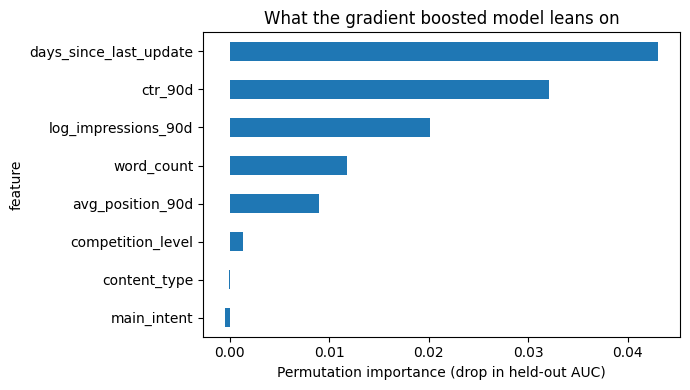

wrote work/figures/permutation_importance.png
wrote work/metrics/capstone_metrics.json
{
  "lane": "Refresh / Content Opportunity Scoring",
  "feature_window": "month=2026-03",
  "label_window": "month=2026-04 (30-day forward)",
  "split": "client-grouped, GroupShuffleSplit, test_size=0.25, random_state=42",
  "base_rate_future_decline": 0.514,
  "logistic_regression": {
    "auc": 0.639,
    "precision_at_50": 0.7
  },
  "gradient_boosted_trees": {
    "auc": 0.589,
    "precision_at_50": 0.48
  },
  "reason_code_counts": {
    "monitor_only": 35415,
    "model_flagged_only": 28052,
    "low_ctr_visible_page": 8532,
    "stale_visible_page": 5427,
    "low_ctr_and_stale": 4836
  }
}


In [7]:
import os, json
os.makedirs('work/figures', exist_ok=True)
os.makedirs('work/metrics', exist_ok=True)

import matplotlib.pyplot as plt
from sklearn.inspection import permutation_importance

perm = permutation_importance(
    clf_gb, gb_test[features_context], gb_test['future_decline'],
    scoring='roc_auc', n_repeats=10, random_state=42
)
importance_table = pd.DataFrame({
    'feature': features_context,
    'importance_mean': perm.importances_mean,
}).sort_values('importance_mean', ascending=False).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(7, 4))
importance_table.sort_values('importance_mean').plot.barh(x='feature', y='importance_mean', ax=ax, legend=False)
ax.set_xlabel('Permutation importance (drop in held-out AUC)')
ax.set_title('What the gradient boosted model leans on')
plt.tight_layout()
plt.savefig('work/figures/permutation_importance.png', dpi=150)
plt.show()

metrics_summary = {
    'lane': 'Refresh / Content Opportunity Scoring',
    'feature_window': 'month=2026-03',
    'label_window': 'month=2026-04 (30-day forward)',
    'split': 'client-grouped, GroupShuffleSplit, test_size=0.25, random_state=42',
    'base_rate_future_decline': round(float(base_rate), 3),
    'logistic_regression': {'auc': round(float(lr_auc), 3), 'precision_at_50': round(float(lr_p50), 2)},
    'gradient_boosted_trees': {'auc': round(float(gb_auc), 3), 'precision_at_50': round(float(gb_p50), 2)},
    'reason_code_counts': ranked_queue['reason_code'].value_counts().to_dict(),
}
with open('work/metrics/capstone_metrics.json', 'w') as f:
    json.dump(metrics_summary, f, indent=2)

print('wrote work/figures/permutation_importance.png')
print('wrote work/metrics/capstone_metrics.json')
print(json.dumps(metrics_summary, indent=2))

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.